In [3]:
import json
import subprocess
import os
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset


# Resolve repository root from git
REPO_ROOT = Path(
    subprocess.check_output(["git", "rev-parse", "--show-toplevel"])  # nosec - local repo query
    .decode()
    .strip()
)
os.chdir(REPO_ROOT)
from models.fno import FNO1d, LpLoss, count_params
DATA_DIR = REPO_ROOT / "data"
OUTPUTS_DIR = REPO_ROOT / "outputs"

# Plot styling
plt.rcParams["font.family"] = "DejaVu Serif"
title_font = {"family": "DejaVu Serif", "weight": "bold", "size": 12}

DEVICE = "cuda:1"
print(f"Repo root: {REPO_ROOT}")
print(f"Using device: {DEVICE}")

Repo root: /home/johnma/dno-fno
Using device: cuda:1


In [ ]:
# --- User configuration ---
# Set the run directory (stored in outputs/)
RUN_DIR = OUTPUTS_DIR / "fno_20260218_143610"

# Dataset artifacts
DATASET_NAME = "stokes_dno_training_ichoi0.npz"  # processed npz built via process_stokes.py
MAT_METADATA = DATA_DIR / "stokes_dno_training_ichoi0.mat"  # for x-grid + raw fields

# Evaluation options
BATCH_SIZE = 64
TEST_FRACTION = 0.1
SEED = 0  # must match train/1d_dno_fno.py
NUM_WORKERS = 0

assert RUN_DIR.exists(), f"Run directory {RUN_DIR} not found"
assert (DATA_DIR / DATASET_NAME).exists(), "Dataset npz missing"
assert MAT_METADATA.exists(), "MAT metadata file missing"
print(f"Evaluating run: {RUN_DIR}")

Evaluating grid: /home/johnma/dno-fno/outputs/fno_20260204_024110/grid_05


In [ ]:
# Helper utilities mirroring train/1d_dno_fno.py

def load_run_config(run_dir: Path) -> dict:
    config_path = run_dir / "config.json"
    with open(config_path, "r", encoding="utf-8") as f:
        config = json.load(f)
    state_path = run_dir / "best_model.pt"
    if not state_path.exists():
        raise FileNotFoundError(f"Missing best_model.pt in {run_dir}")
    config["state_path"] = state_path
    return config


def load_processed_dataset(npz_path: Path) -> dict:
    data = np.load(npz_path)
    required = {"eta", "xi", "Gxi"}
    missing = required - set(data.files)
    if missing:
        raise KeyError(f"Dataset {npz_path} missing keys: {missing}")
    return {key: data[key] for key in data.files}


def build_feature_target_tensors(dataset: dict) -> tuple[torch.Tensor, torch.Tensor]:
    eta = dataset["eta"][..., None]
    xi = dataset["xi"][..., None]
    inputs = np.concatenate([eta, xi], axis=-1)  # (N, Nx, 2)
    targets = dataset["Gxi"][..., None] # (N, Nx, 1)
    return (
        torch.tensor(inputs, dtype=torch.float32),
        torch.tensor(targets, dtype=torch.float32),
    )


def normalize_to_range(data: torch.Tensor, min_val: float = -1.0, max_val: float = 1.0):
    d_min = data.min()
    d_max = data.max()
    norm_data = (data - d_min) / (d_max - d_min + 1e-8) * (max_val - min_val) + min_val
    stats = {"min": d_min, "max": d_max}
    return norm_data, stats


def denormalize_from_range(norm_data: torch.Tensor, stats: dict, min_val: float = -1.0, max_val: float = 1.0):
    d_min = stats["min"].to(norm_data.device)
    d_max = stats["max"].to(norm_data.device)
    return (norm_data - min_val) / (max_val - min_val) * (d_max - d_min + 1e-8) + d_min


In [ ]:
# Load dataset + rebuild test split identical to simplified training
npz_data = load_processed_dataset(DATA_DIR / DATASET_NAME)
features_raw, targets_raw = build_feature_target_tensors(npz_data)

features_norm, feat_stats = normalize_to_range(features_raw)
targets_norm, target_stats = normalize_to_range(targets_raw)

n_samples = len(features_norm)
indices = np.arange(n_samples)
test_size = int(n_samples * TEST_FRACTION)
test_idx = indices[:test_size] # Flat split matching new train/1d_dno_fno.py

print(f"Total samples: {n_samples} | Test count: {len(test_idx)}")

test_dataset = TensorDataset(
    features_norm[test_idx],
    targets_raw[test_idx], # keep raw target for metrics
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)

Total samples: 19992 | Test count: 1999


In [19]:
# Load spatial grid (x) from MATLAB metadata for plotting
with h5py.File(MAT_METADATA, "r") as f:
    x_grid = np.array(f["x"]).squeeze()
    if x_grid.ndim > 1:
        x_grid = x_grid.T
    x_grid = np.asarray(x_grid).ravel()

print(f"Loaded x-grid with {x_grid.size} points")

Loaded x-grid with 8192 points


In [ ]:
# Load run configuration and rebuild FNO
config = load_run_config(RUN_DIR)
print("Loaded config:")
for k, v in config.items():
    if k != "state_path":
        print(f"  {k}: {v}")
print(f"Model checkpoint: {config['state_path']}")

# Pass n_blocks if present in config, else defaults to 4
n_blocks = config.get("n_blocks", 4)
model = FNO1d(config["modes"], config["width"], n_blocks=n_blocks).to(DEVICE)
state_dict = torch.load(config["state_path"], map_location=DEVICE)
model.load_state_dict(state_dict)
model.eval()
print(f"Param count: {count_params(model):,}")

Loaded config:
  modes: 16
  width: 48
  batch_size: 16
  lr: 0.005
  epochs: 200
  weight_decay: 0.0001
  param_count: 163409
Model checkpoint: /home/johnma/dno-fno/outputs/fno_20260204_024110/grid_05/final_model.pt
Param count: 163,409


In [ ]:
# Evaluate on test set: collect predictions + per-sample relative errors
all_preds = []
rel_l2 = []
rel_l1 = []

with torch.no_grad():
    for batch in test_loader:
        x_norm, y_true = batch
        x_norm = x_norm.to(DEVICE)
        y_true = y_true.to(DEVICE)

        pred_norm = model(x_norm)

        # Denormalize predictions using target stats
        pred = denormalize_from_range(pred_norm, target_stats)

        all_preds.append(pred.cpu())

        flat_pred = pred.view(pred.size(0), -1)
        flat_true = y_true.view(y_true.size(0), -1)

        rel_l2.append(
            torch.norm(flat_pred - flat_true, dim=1) / (torch.norm(flat_true, dim=1) + 1e-12)
        )
        rel_l1.append(
            torch.sum(torch.abs(flat_pred - flat_true), dim=1)
            / (torch.sum(torch.abs(flat_true), dim=1) + 1e-12)
        )

predictions = torch.cat(all_preds, dim=0)
errors_l2 = torch.cat(rel_l2, dim=0)
errors_l1 = torch.cat(rel_l1, dim=0)

print("Test metrics:")
print(f"  Mean Rel L2: {errors_l2.mean().item():.6f}")
print(f"  Median Rel L2: {errors_l2.median().item():.6f}")
print(f"  Mean Rel L1: {errors_l1.mean().item():.6f}")
print(f"  Median Rel L1: {errors_l1.median().item():.6f}")

Test metrics:
  Mean Rel L2: 0.338673
  Median Rel L2: 0.052029
  Mean Rel L1: 0.310191
  Median Rel L1: 0.036170


In [ ]:
# Summarize scalar metrics
summary = {
    "run_dir": str(RUN_DIR.relative_to(REPO_ROOT)),
    "param_count": count_params(model),
    "mean_rel_l2": errors_l2.mean().item(),
    "median_rel_l2": errors_l2.median().item(),
    "std_rel_l2": errors_l2.std().item(),
    "mean_rel_l1": errors_l1.mean().item(),
    "median_rel_l1": errors_l1.median().item(),
    "std_rel_l1": errors_l1.std().item(),
}
summary

{'grid_dir': 'outputs/fno_20260204_024110/grid_05',
 'param_count': 163409,
 'mean_rel_l2': 0.3386732041835785,
 'median_rel_l2': 0.052029214799404144,
 'std_rel_l2': 0.42379048466682434,
 'mean_rel_l1': 0.310190886259079,
 'median_rel_l1': 0.03617025166749954,
 'std_rel_l1': 0.41054069995880127}

In [31]:
# Select representative samples
num_samples = len(predictions)
sorted_indices = torch.argsort(errors_l2)

sample_indices = {
    "best": sorted_indices[0].item(),
    "median": sorted_indices[num_samples // 2].item(),
    "worst": sorted_indices[-1].item(),
    "random": int(torch.randint(0, num_samples, (1,)).item()),
}

sample_indices

{'best': 1417, 'median': 1606, 'worst': 374, 'random': 267}

In [32]:
# Prepare raw fields for plotting (eta, xi, Gxi) for test indices
eta_raw = torch.tensor(npz_data["eta"], dtype=torch.float32)[test_idx]
xi_raw = torch.tensor(npz_data["xi"], dtype=torch.float32)[test_idx]
Gxi_raw = torch.tensor(npz_data["Gxi"], dtype=torch.float32)[test_idx]

nx = eta_raw.shape[1]
if x_grid.size != nx:
    x_plot = np.linspace(x_grid.min(), x_grid.max(), nx)
else:
    x_plot = x_grid

print(f"Plotting grid size: {nx}")

Plotting grid size: 8192


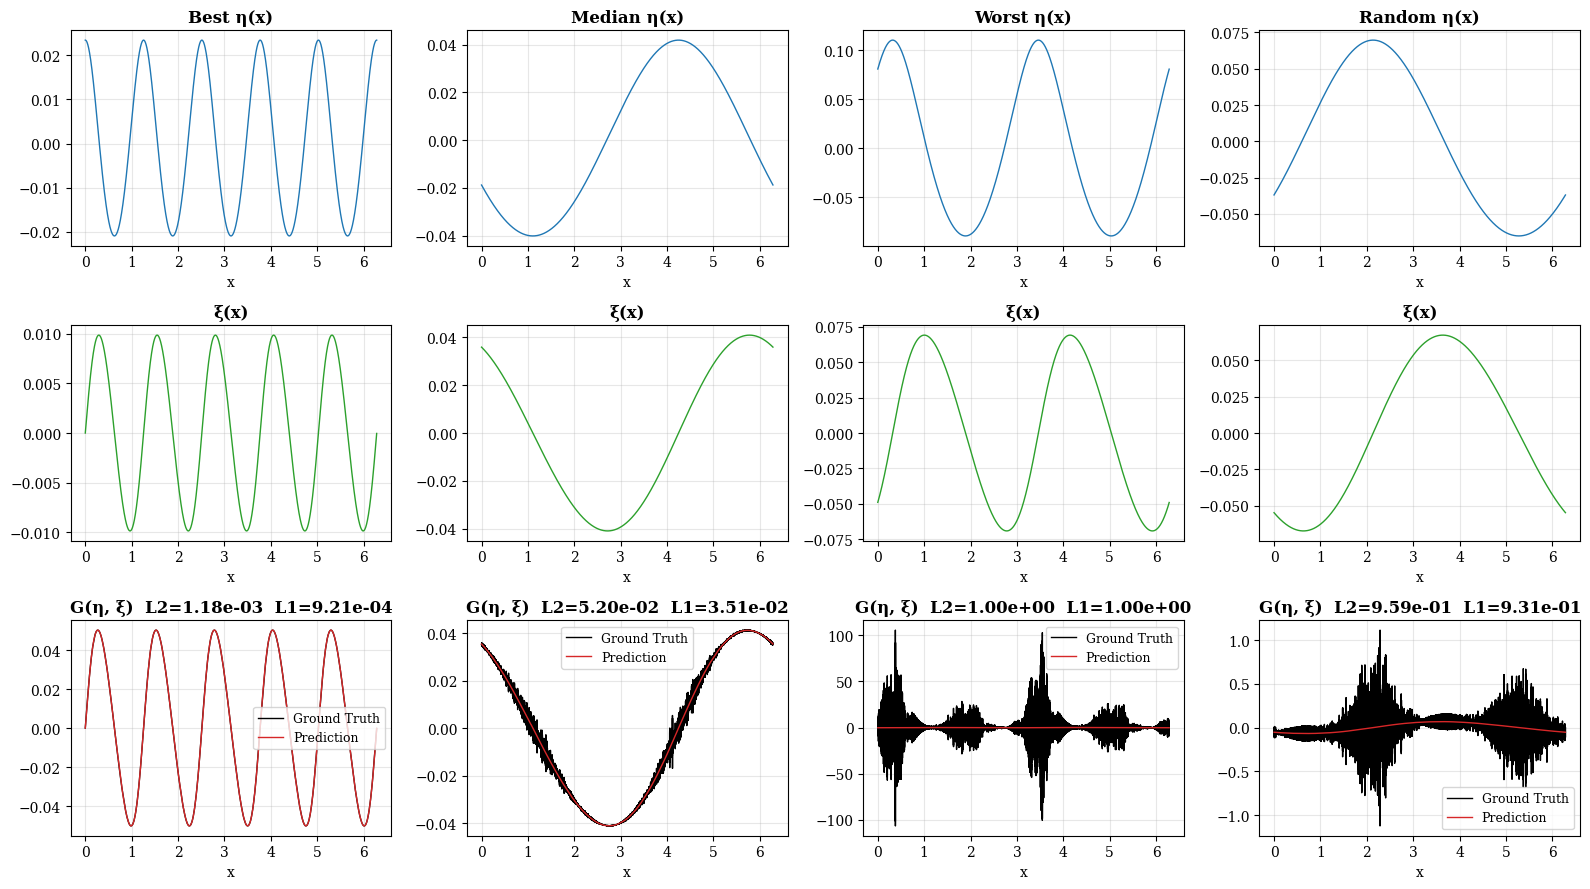

In [33]:
# Plot best / median / worst / random predictions
fig, axes = plt.subplots(3, 4, figsize=(16, 9))
order = ["best", "median", "worst", "random"]

for col, key in enumerate(order):
    idx = sample_indices[key]
    err_l2 = errors_l2[idx].item()
    err_l1 = errors_l1[idx].item()

    axes[0, col].plot(x_plot, eta_raw[idx].numpy(), color="tab:blue", linewidth=1.0)
    axes[0, col].set_title(f"{key.title()} η(x)", fontdict=title_font)
    axes[0, col].set_xlabel("x")
    axes[0, col].grid(True, alpha=0.3)

    axes[1, col].plot(x_plot, xi_raw[idx].numpy(), color="tab:green", linewidth=1.0)
    axes[1, col].set_title("ξ(x)", fontdict=title_font)
    axes[1, col].set_xlabel("x")
    axes[1, col].grid(True, alpha=0.3)

    axes[2, col].plot(x_plot, Gxi_raw[idx].numpy(), label="Ground Truth", color="black", linewidth=1.0)
    axes[2, col].plot(x_plot, predictions[idx].cpu().numpy(), label="Prediction", color="tab:red", linewidth=1.0)
    axes[2, col].set_title(f"G(η, ξ)  L2={err_l2:.2e}  L1={err_l1:.2e}", fontdict=title_font)
    axes[2, col].set_xlabel("x")
    axes[2, col].grid(True, alpha=0.3)
    axes[2, col].legend(fontsize=9)

plt.tight_layout()
plt.show()